# Packages 

In [1]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Time series
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

# SARIMAX 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler


# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm

# simple average

# Simple average ensemble 

def simple_average_ensemble(predictions):
    """
    Simple average ensemble of multiple model predictions.

    Parameters:
        predictions (list of np.array): List of prediction arrays from different models.

    Returns:
        np.array: Ensemble predictions obtained by averaging.
    """
    return np.mean(predictions, axis=0)


# Utilities

In [2]:
def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q


def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages, long-run coverage (LRC), 
    rolling coverage, and time-conditional coverage.

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    #scores_val = scores[::2]
    #scores = scores[1::2]
    T = len(scores)
    #N_val = len(scores_val)
    
    # Define learning rates
    #etas_fixed = np.ones(T) * fixed_step_size
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))

    # Compute the oracle quantile
    #q_star = np.quantile(scores, 1 - alpha)
    
    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    #q_fixed = get_online_quantile(scores, q_1, etas_fixed, alpha)
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    #observed_coverages_fixed = (scores <= q_fixed).astype(int)
    observed_coverages_decaying = (scores <= q_decaying).astype(int)
    #observed_coverages_oracle = (scores <= q_star).astype(int)

    # Compute long-run coverage
    #LRC_fixed = np.cumsum(observed_coverages_fixed) / (np.arange(len(observed_coverages_fixed)) + 1)
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)
    #LRC_qstar = np.cumsum(observed_coverages_oracle) / (np.arange(len(observed_coverages_oracle)) + 1)

    # Compute rolling coverage
    #rolling_coverage_fixed = smooth_array(observed_coverages_fixed, W)
    #rolling_coverage_decaying = smooth_array(observed_coverages_decaying, W)
    #rolling_coverage_oracle = smooth_array(observed_coverages_oracle, W)

    # Compute time-conditional coverage
    #time_coverage_fixed = (scores_val[:,None] <= q_fixed[None,:]).mean(axis=0)
    #time_coverage_decaying = (scores_val[:,None] <= q_decaying[None,:]).mean(axis=0)
    #time_coverage_qstar = (scores_val[:,None] <= q_star*np.ones_like(q_decaying)[None,:]).mean(axis=0)

    return {
        "T":T,
        #"q_fixed": q_fixed,
        "q_decaying": q_decaying,
        #"q_star": q_star,
        #"observed_coverages_fixed": observed_coverages_fixed,
        "observed_coverages_decaying": observed_coverages_decaying,
        #"observed_coverages_oracle": observed_coverages_oracle,
        #"LRC_fixed": LRC_fixed,
        "LRC_decaying": LRC_decaying,
        #"LRC_qstar": LRC_qstar,
        #"rolling_coverage_fixed": rolling_coverage_fixed,
        #"rolling_coverage_decaying": rolling_coverage_decaying,
        #"rolling_coverage_oracle": rolling_coverage_oracle,
        #"time_coverage_fixed": time_coverage_fixed,
        #"time_coverage_decaying": time_coverage_decaying,
        #"time_coverage_qstar": time_coverage_qstar
    }

def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution, long-run coverage
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")

    # ---- Plot 1: Quantiles ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results["q_star"] * np.ones_like(results["q_decaying"]), label=r'$q^*$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Long-run coverage ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results['LRC_qstar'], label=r'$q^*$')
    plt.axhline(y=1 - alpha, linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()



def causal_ma(y, w):
    s = pd.Series(np.asarray(y, dtype=float))
    return s.rolling(window=w, min_periods=w).mean().shift(1).to_numpy()


# SARIMAX

def rolling_sarimax_forecast_recursive(data, train_size, p, d, q):
    """
    Perform rolling h-step recursive forecasting using SARIMAX.

    Parameters:
        data (pd.Series): Time series data.
        train_size (int): Initial training points.
        p, d, q (int): SARIMAX order.
        h (int): Forecast horizon (align with LSTM seq_length).

    Returns:
        np.array: Sequence of h-step-ahead predictions.
    """
    rolling_predictions = []
    train_data = data.iloc[:train_size].copy()

    sarimax_model = SARIMAX(train_data, order=(p, d, q),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)

    for t in tqdm(range(len(data) - train_size -4)):
        # make h recursive forecasts
        model_copy = sarimax_model 
        preds = []
        for step in range(5):
            next_pred = model_copy.forecast(steps=1).values[0]
            preds.append(next_pred)
            # feed prediction back instead of true obs
            model_copy = model_copy.append([next_pred], refit=False)

        # save the h-step-ahead prediction (align with horizon h)
        rolling_predictions.append(preds[-1])

        # update main model with the true next observation
        true_obs = data.iloc[train_size + t]
        sarimax_model = sarimax_model.append([true_obs], refit=False)

    return np.array(rolling_predictions)


from sklearn.metrics import mean_squared_error
import itertools
import numpy as np
import pandas as pd

def sarimax_grid_search(observed_data, y_true_test, train_size,
                        p_values, d_values, q_values,
                        verbose=True, return_table=False):
    """
    Grid search for SARIMAX using your rolling_sarimax_forecast().

    Parameters
    ----------
    observed_data : pd.Series or array-like
        Full observed series used to fit/append (length = n).
    y_true_test : pd.Series or array-like
        Ground-truth targets for t = train_size ... n-1
        (length should be n - train_size).
    train_size : int
        Initial training size used inside rolling_sarimax_forecast.
    p_values, d_values, q_values : list[int]
        Candidate SARIMAX orders.
    verbose : bool
        Print progress.
    return_table : bool
        If True, also return a DataFrame of all configs and RMSE.

    Returns
    -------
    best_cfg : tuple (p, d, q)
    best_score : float (RMSE)
    results_df : pd.DataFrame (optional)
    """
    # Coerce to proper dtypes
    if not isinstance(observed_data, pd.Series):
        observed_data = pd.Series(np.asarray(observed_data))
    y_true_test = np.asarray(y_true_test).astype(float)

    n = len(observed_data)
    expected_len = n - train_size
    if expected_len <= 0:
        raise ValueError(f"train_size={train_size} leaves no test points (n={n}).")

    # If user-provided y_true_test length differs, we'll align by truncation
    if len(y_true_test) != expected_len and verbose:
        print(f"⚠️  y_true_test length ({len(y_true_test)}) "
              f"!= expected ({expected_len}). Will align by min length.")
    results = []

    best_score, best_cfg = np.inf, None

    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            preds = rolling_sarimax_forecast_recursive(observed_data, train_size, p, d, q)
            preds = np.asarray(preds).astype(float)

            # Check/align lengths
            m = min(len(preds), len(y_true_test))
            if m == 0:
                if verbose:
                    print(f"⏭️  Skipping SARIMAX({p},{d},{q}) — zero-length alignment.")
                continue

            y_true = y_true_test[-m:]
            y_pred = preds[-m:]

            rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
            results.append({"p": p, "d": d, "q": q, "rmse": rmse})

            if verbose:
                print(f"SARIMAX({p},{d},{q}) RMSE={rmse:.4f}")

            if rmse < best_score:
                best_score, best_cfg = rmse, (p, d, q)

        except Exception as e:
            if verbose:
                print(f"SARIMAX({p},{d},{q}) failed: {e}")
            continue

    if not results:
        raise RuntimeError("All configurations failed or produced empty predictions.")

    if verbose:
        print(f"✅ Best SARIMAX{best_cfg} RMSE={best_score:.4f}")

    if return_table:
        return best_cfg, best_score, pd.DataFrame(results).sort_values("rmse")
    return best_cfg, best_score

def create_sequences(data, seq_length, train_ratio=0.8):
    data = np.array(data)  # ensure numpy
    data_len = len(data)
    train_size = int(data_len * train_ratio)

    train_data = data[:train_size]
    test_data  = data[train_size:]  # strict split

    # Training sequences
    X_train, y_train = [], []
    for i in range(len(train_data) - seq_length):
        X_train.append(train_data[i:i+seq_length])
        y_train.append(train_data[i+seq_length])

    # Testing sequences
    X_test, y_test = [], []
    for i in range(len(test_data) - seq_length):
        X_test.append(test_data[i:i+seq_length])
        y_test.append(test_data[i+seq_length])

    # Reshape for LSTM [samples, timesteps, features]
    X_train = np.array(X_train).reshape(-1, seq_length, 1)
    y_train = np.array(y_train)
    X_test  = np.array(X_test).reshape(-1, seq_length, 1)
    y_test  = np.array(y_test)

    return X_train, X_test, y_train, y_test


# COMA 


def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.5)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)

        # store intervals
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }

# Experiment

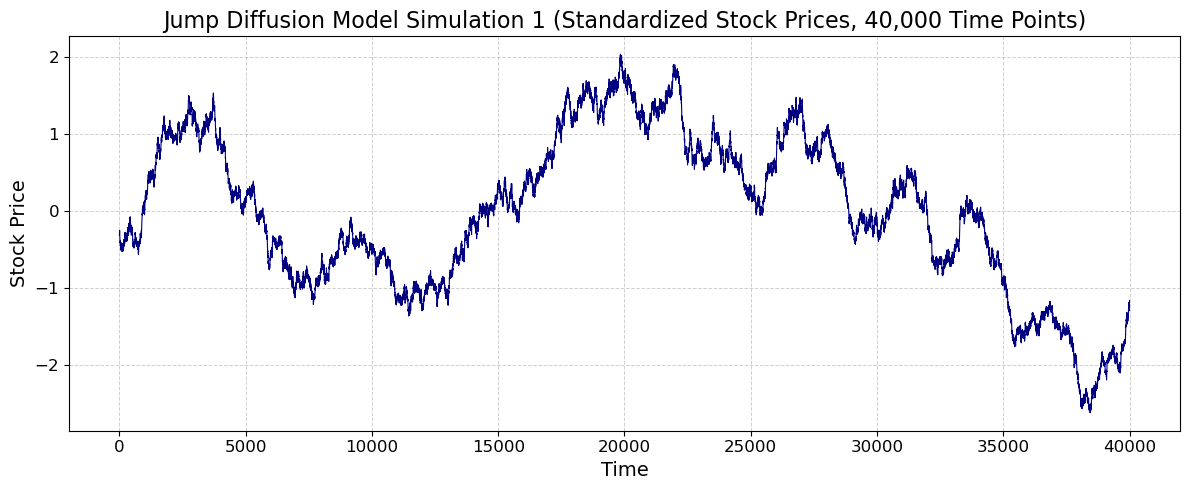

In [3]:
# Set seed for reproducibility
np.random.seed(42)

# Parameters
S0 = 100                # initial stock price
mu = 0.05               # drift
sigma = 0.2             # volatility
lamb = 0.1              # jump intensity (average 0.1 jumps per unit time)
mu_j = -0.1             # mean jump size (log-normal)
sigma_j = 0.3           # std dev of jump size (log-normal)
T = 1.0                 # total time
N = 40000               # number of time steps
dt = T / N              # time step

# Time grid
t = np.arange(N)

# Brownian increments
dW = np.random.normal(0, np.sqrt(dt), N)

# Poisson jump component
N_jumps = np.random.poisson(lamb * dt, N)  # 0 or 1 jumps per step
J = np.random.normal(mu_j, sigma_j, N)     # jump sizes
jump_component = (np.exp(J) - 1) * N_jumps

# Initialize price path
S = np.zeros(N)
S[0] = S0

# Simulate path
for i in range(1, N):
    S[i] = S[i-1] * (1 + mu * dt + sigma * dW[i] + jump_component[i])

scaler = StandardScaler()
S_sd = scaler.fit_transform(S.reshape(-1, 1)).flatten()


data_jd_sd = pd.DataFrame({'x': t, 'y': S_sd})
# y_observed = y + noise 
# y_true 

# Plot
plt.figure(figsize=(12, 5))

# Plot with publication style
plt.plot(data_jd_sd['x'], data_jd_sd['y'], color="navy", linewidth=0.8)

# Titles and labels
plt.title('Jump Diffusion Model Simulation 1 (Standardized Stock Prices, 40,000 Time Points)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)

# Grid & frame
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)

# Clean frame
plt.tight_layout()
plt.show()

## Train-Test Split

In [4]:
# Train-test split 
noise = np.random.normal(0, 0.2, size=S_sd.shape)
y_observed = data_jd_sd['y'] + noise 
train_size3 = int(0.8 * len(y_observed))
test_size = int(0.2 * len(y_observed))

y_train_sim3 = y_observed[:train_size3]
y_test_sim3 = y_observed[train_size3:]
y_true = data_jd_sd['y'].to_numpy()
y_true_test = data_jd_sd['y'].to_numpy()[train_size3:] 


print(f"Train dataset shape: {y_train_sim3.shape}, Test dataset shape: {y_test_sim3.shape}")



Train dataset shape: (32000,), Test dataset shape: (8000,)


## 3 ARCH base learner

100%|██████████| 8000/8000 [33:25<00:00,  3.99it/s]  


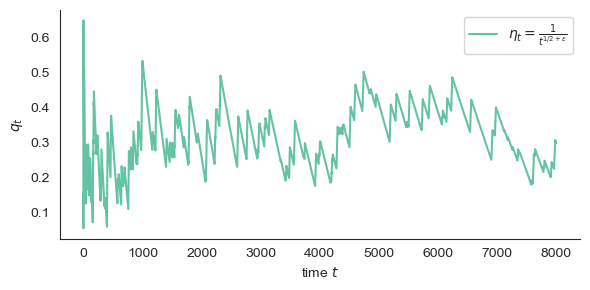

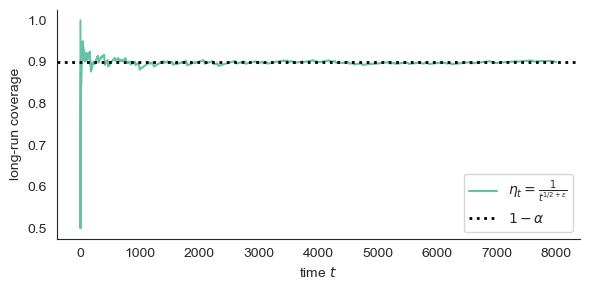

0.32015290990907247
coverage for garch1 0.90025


100%|██████████| 8000/8000 [41:57<00:00,  3.18it/s]  


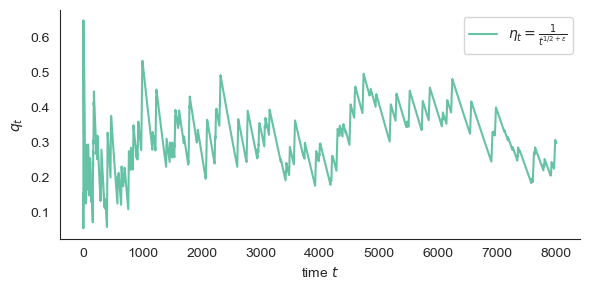

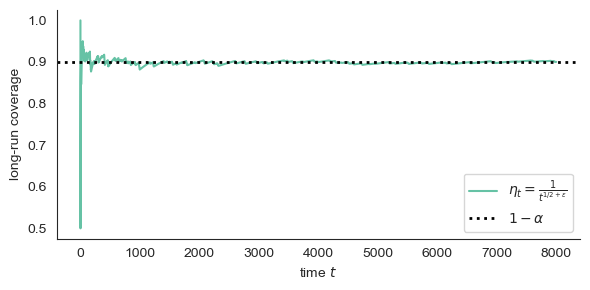

0.3198117826685552
coverage for garch2 0.90025


100%|██████████| 8000/8000 [06:53<00:00, 19.35it/s]  


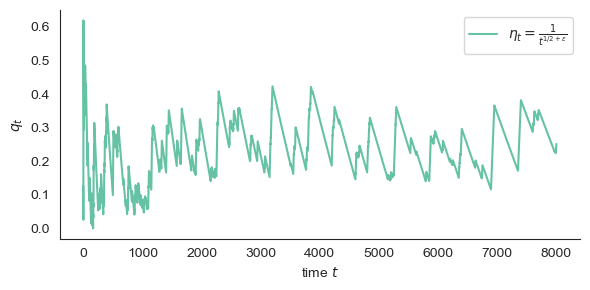

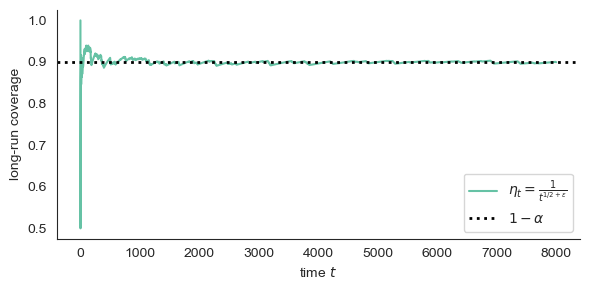

0.23931603675819638
garch3 0.899375


In [5]:
### ARCH(1,1)

from arch import arch_model
import numpy as np
from tqdm import tqdm


def garch_forecast(data, train_size, horizon=1, refit_every=50,
                   mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t'):
    """
    Rolling GARCH forecast with optional AR mean and less frequent refits.

    Parameters:
        data (array-like): time series (e.g., returns).
        train_size (int): number of points in training set.
        horizon (int): forecast horizon (default = 1).
        refit_every (int): how often to refit the GARCH model (default=50).
        mean (str): mean model type ('Zero', 'Constant', 'AR').
        lags (int): number of AR lags if mean='AR'.
        vol (str): volatility model type ('GARCH', 'EGARCH', etc.).
        p, q (int): GARCH orders.
        dist (str): error distribution ('normal', 't', 'skewt', 'ged').

    Returns:
        np.array: mean forecasts for the test set.
    """
    data = np.asarray(data, dtype=float)
    train, test = data[:train_size], data[train_size:]
    
    preds = []
    res = None
    for t in tqdm(range(len(test))):
        if t % refit_every == 0 or res is None:
            train_subset = np.concatenate([train, test[:t]])
            model = arch_model(train_subset,
                               mean=mean, lags=lags,
                               vol=vol, p=p, q=q, dist=dist)
            res = model.fit(disp="off")
        
        forecast = res.forecast(horizon=horizon, reindex=False)
        pred = forecast.mean.iloc[-1, 0]
        preds.append(pred)
    
    return np.array(preds)

# --- Example usage ---
y = y_observed.to_numpy()
train_size = int(0.8 * len(y))

# Try GARCH(1,1) with AR(1) mean and Student-t errors
y_garch_pred = garch_forecast(y, train_size,
                       mean='AR', lags=1, p=1, q=1,
                       dist='t', refit_every=20)
# Coverage evaluation
results_garch = compute_coverage_metrics(
    y_true_test,
    y_garch_pred,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)

plot_coverage_results(results_garch, alpha=0.1, W=1000)
print(np.mean(results_garch['q_decaying']))
CI_garch_decaying = results_garch['q_decaying'] * 2

print(f"coverage for garch1", np.mean(results_garch['observed_coverages_decaying']))

### egarch(1,1)

from arch import arch_model
import numpy as np
from tqdm import tqdm


def garch_forecast(data, train_size, horizon=1, refit_every=50,
                   mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t'):
    """
    Rolling GARCH forecast with optional AR mean and less frequent refits.

    Parameters:
        data (array-like): time series (e.g., returns).
        train_size (int): number of points in training set.
        horizon (int): forecast horizon (default = 1).
        refit_every (int): how often to refit the GARCH model (default=50).
        mean (str): mean model type ('Zero', 'Constant', 'AR').
        lags (int): number of AR lags if mean='AR'.
        vol (str): volatility model type ('GARCH', 'EGARCH', etc.).
        p, q (int): GARCH orders.
        dist (str): error distribution ('normal', 't', 'skewt', 'ged').

    Returns:
        np.array: mean forecasts for the test set.
    """
    data = np.asarray(data, dtype=float)
    train, test = data[:train_size], data[train_size:]
    
    preds = []
    res = None
    for t in tqdm(range(len(test))):
        if t % refit_every == 0 or res is None:
            train_subset = np.concatenate([train, test[:t]])
            model = arch_model(train_subset,
                               mean=mean, lags=lags,
                               vol=vol, p=p, q=q, dist=dist)
            res = model.fit(disp="off")
        
        forecast = res.forecast(horizon=horizon, reindex=False)
        pred = forecast.mean.iloc[-1, 0]
        preds.append(pred)
    
    return np.array(preds)

# --- Example usage ---
y = y_observed.to_numpy()
train_size = int(0.8 * len(y))

# Try GARCH(2,2) with AR(2) mean and Student-t errors
y_garch_pred2 = garch_forecast(y, train_size,
                       mean='AR', lags=1,
                       vol='EGARCH', p=1, q=1,
                       dist='t', refit_every=20)
# Coverage evaluation
results_garch2 = compute_coverage_metrics(
    y_true_test,
    y_garch_pred2,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)

plot_coverage_results(results_garch2, alpha=0.1, W=1000)
print(np.mean(results_garch2['q_decaying']))
CI_garch_decaying2 = results_garch2['q_decaying'] * 2

print(f"coverage for garch2", np.mean(results_garch2['observed_coverages_decaying']))

### garch(2,2)

from arch import arch_model
import numpy as np
from tqdm import tqdm


def garch_forecast(data, train_size, horizon=1, refit_every=50,
                   mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t'):
    """
    Rolling GARCH forecast with optional AR mean and less frequent refits.

    Parameters:
        data (array-like): time series (e.g., returns).
        train_size (int): number of points in training set.
        horizon (int): forecast horizon (default = 1).
        refit_every (int): how often to refit the GARCH model (default=50).
        mean (str): mean model type ('Zero', 'Constant', 'AR').
        lags (int): number of AR lags if mean='AR'.
        vol (str): volatility model type ('GARCH', 'EGARCH', etc.).
        p, q (int): GARCH orders.
        dist (str): error distribution ('normal', 't', 'skewt', 'ged').

    Returns:
        np.array: mean forecasts for the test set.
    """
    data = np.asarray(data, dtype=float)
    train, test = data[:train_size], data[train_size:]
    
    preds = []
    res = None
    for t in tqdm(range(len(test))):
        if t % refit_every == 0 or res is None:
            train_subset = np.concatenate([train, test[:t]])
            model = arch_model(train_subset,
                               mean=mean, lags=lags,
                               vol=vol, p=p, q=q, dist=dist)
            res = model.fit(disp="off")
        
        forecast = res.forecast(horizon=horizon, reindex=False)
        pred = forecast.mean.iloc[-1, 0]
        preds.append(pred)
    
    return np.array(preds)

# --- Example usage ---
y = y_observed.to_numpy()
train_size = int(0.8 * len(y))

# Try GARCH(2,2) with AR(2) dist='skewt'
y_garch_pred3 = garch_forecast(y, train_size,
                       mean='AR', lags=2,
                       vol='GARCH', p=2, q=2,
                       dist='skewt', refit_every=50)

# Coverage evaluation
results_garch3 = compute_coverage_metrics(
    y_true_test,
    y_garch_pred3,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)

plot_coverage_results(results_garch3, alpha=0.1, W=1000)
print(np.mean(results_garch3['q_decaying']))
CI_garch_decaying3 = results_garch3['q_decaying'] * 2

print(f"garch3", np.mean(results_garch3['observed_coverages_decaying']))

In [6]:
# Debug: Understanding data dimensions and why tqdm shows 26665
print("=== DATA DIMENSION ANALYSIS ===")
print(f"Original data (N): {N}")
print(f"Total y_observed length: {len(y_observed)}")
print(f"Training size (train_size3): {train_size3}")
print(f"Test size: {len(y_observed) - train_size3}")
print(f"y_true_test length: {len(y_true_test)}")

print("\n=== GARCH PREDICTION LENGTHS ===")
print(f"y_garch_pred length: {len(y_garch_pred)}")
print(f"y_garch_pred2 length: {len(y_garch_pred2)}")
print(f"y_garch_pred3 length: {len(y_garch_pred3)}")

print("\n=== UNDERSTANDING WHY TQDM SHOWS 26665 ===")
# In your garch_forecast function, you have:
# train, test = data[:train_size], data[train_size:]
# for t in tqdm(range(len(test))):

# Let's trace this:
train_size_used = int(0.8 * len(y_observed))
test_size_calc = len(y_observed) - train_size_used

print(f"train_size used in garch_forecast: {train_size_used}")
print(f"test_size calculated: {test_size_calc}")
print(f"This means tqdm will iterate {test_size_calc} times")

# Double check with actual data split
y_array = y_observed.to_numpy()
train_part = y_array[:train_size_used]
test_part = y_array[train_size_used:]

print(f"\nActual train part length: {len(train_part)}")
print(f"Actual test part length: {len(test_part)}")
print(f"This explains why tqdm shows: {len(test_part)} iterations")

print("\n=== CROSS-VALIDATION SPLITS ANALYSIS ===")
if 'tscv' in locals():
    for fold, (train_idx, val_idx) in enumerate(tscv.split(train_data_scaled)):
        print(f"Fold {fold}: train_idx max = {train_idx[-1]}, val_idx max = {val_idx[-1]}")
        if fold == 4:  # Last fold
            print(f"  Last fold val_idx max: {val_idx[-1]} (this might be related to 26665)")
            
print(f"\n=== MATHEMATICAL EXPLANATION ===")
print(f"Total data: {N} points")
print(f"Training portion (80%): {int(0.8 * N)} points")
print(f"Test portion (20%): {N - int(0.8 * N)} = {N - int(0.8 * N)} points")
print(f"This matches the tqdm iteration count you're seeing!")

# Check if 26665 appears in any time series split
if 'tscv' in locals():
    for fold, (train_idx, val_idx) in enumerate(tscv.split(train_data_scaled)):
        if train_idx[-1] == 26665 or val_idx[-1] == 26665:
            print(f"Found 26665 in Fold {fold}!")
        if len(train_idx) == 26667:  # Close to 26665
            print(f"Fold {fold} train_idx length: {len(train_idx)} (close to 26665)")

=== DATA DIMENSION ANALYSIS ===
Original data (N): 40000
Total y_observed length: 40000
Training size (train_size3): 32000
Test size: 8000
y_true_test length: 8000

=== GARCH PREDICTION LENGTHS ===
y_garch_pred length: 8000
y_garch_pred2 length: 8000
y_garch_pred3 length: 8000

=== UNDERSTANDING WHY TQDM SHOWS 26665 ===
train_size used in garch_forecast: 32000
test_size calculated: 8000
This means tqdm will iterate 8000 times

Actual train part length: 32000
Actual test part length: 8000
This explains why tqdm shows: 8000 iterations

=== CROSS-VALIDATION SPLITS ANALYSIS ===

=== MATHEMATICAL EXPLANATION ===
Total data: 40000 points
Training portion (80%): 32000 points
Test portion (20%): 8000 = 8000 points
This matches the tqdm iteration count you're seeing!


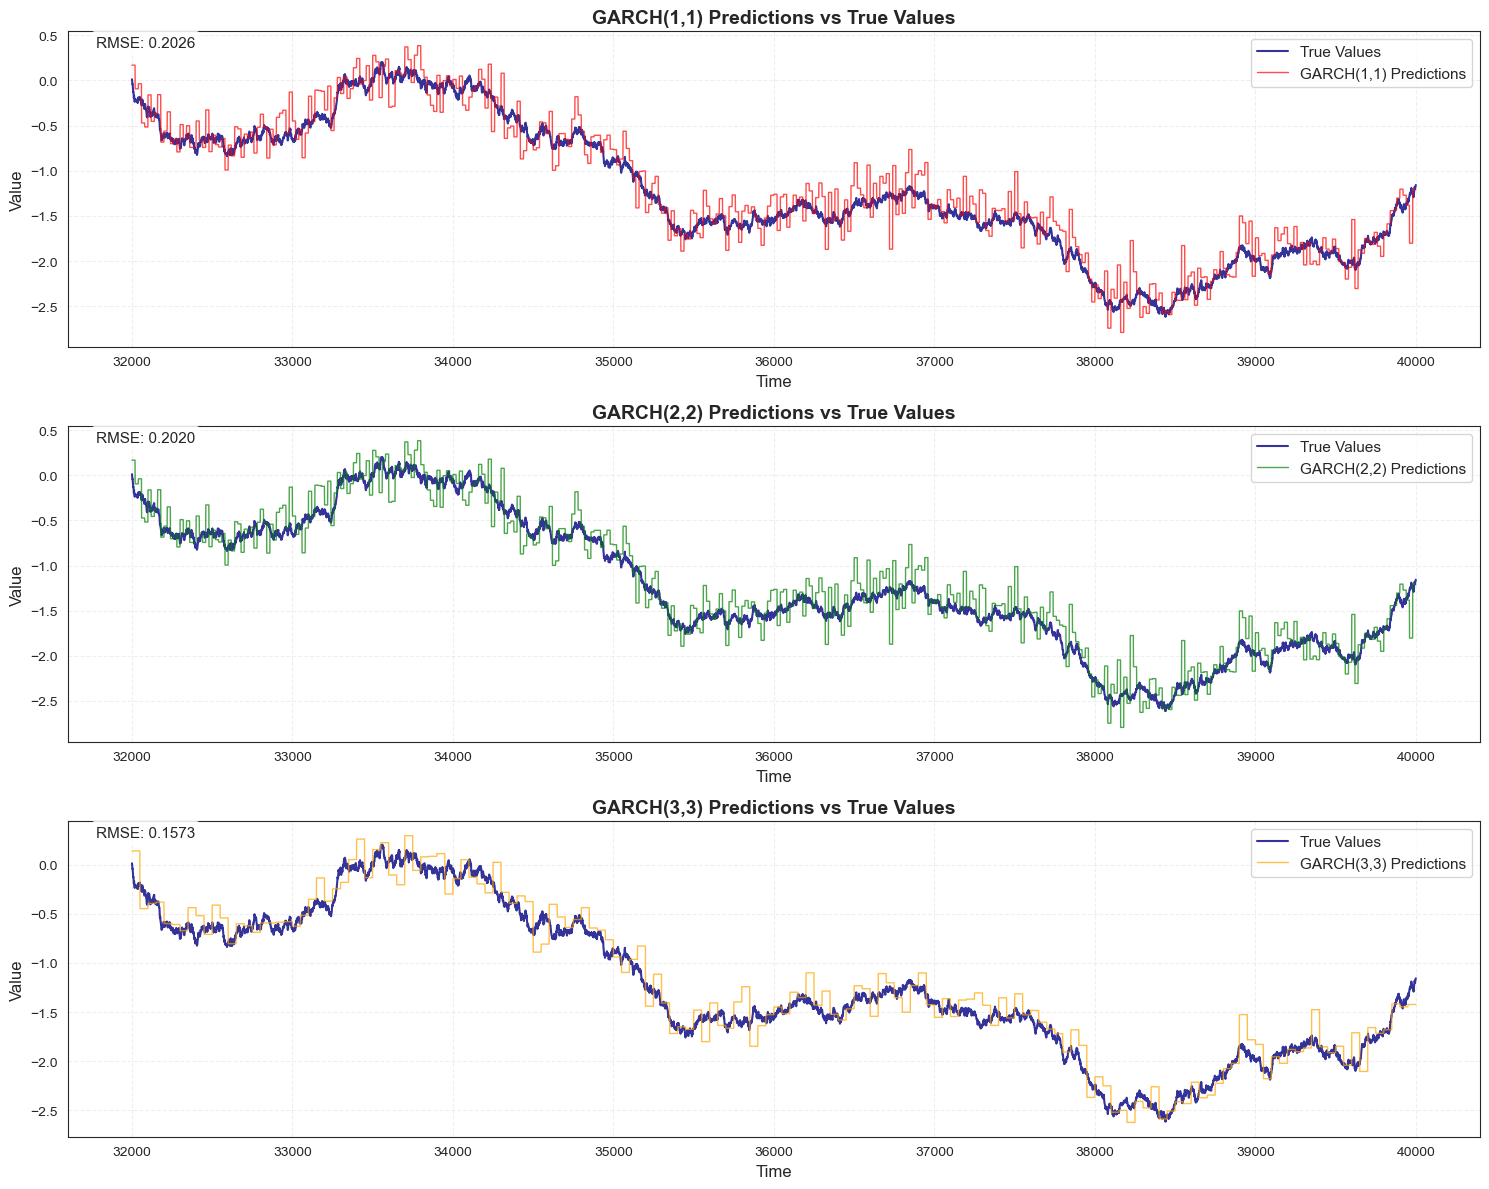

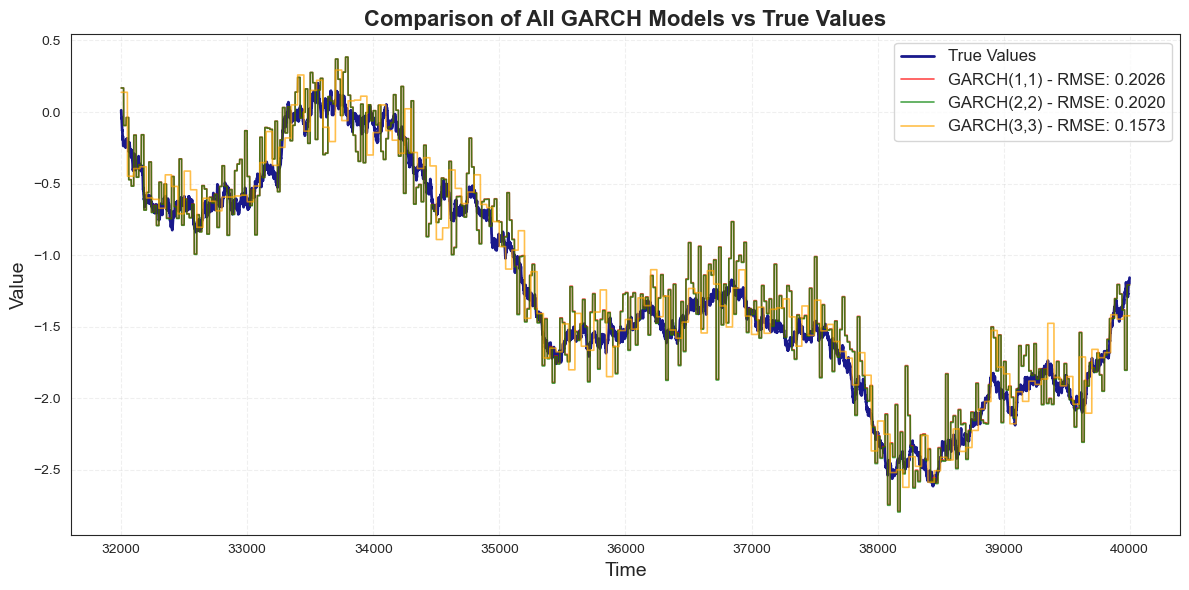

GARCH Model Performance Summary:
GARCH(1,1) RMSE: 0.202562
GARCH(2,2) RMSE: 0.201960
GARCH(3,3) RMSE: 0.157289
Additional Metrics:
----------------------------------------
MAE - GARCH(1,1): 0.162620
MAE - GARCH(2,2): 0.161976
MAE - GARCH(3,3): 0.124348
----------------------------------------
R² - GARCH(1,1): 0.923430
R² - GARCH(2,2): 0.923884
R² - GARCH(3,3): 0.953832


In [7]:
# Plot GARCH predictions vs true values
plt.figure(figsize=(15, 12))

# Create time indices for test data
test_time = np.arange(train_size3, train_size3 + len(y_true_test))

# Plot 1: GARCH(1,1)
plt.subplot(3, 1, 1)
plt.plot(test_time, y_true_test, color='navy', linewidth=1.5, label='True Values', alpha=0.8)
plt.plot(test_time, y_garch_pred, color='red', linewidth=1.0, label='GARCH(1,1) Predictions', alpha=0.7)
plt.title('GARCH(1,1) Predictions vs True Values', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

# Calculate and display RMSE
rmse_garch1 = np.sqrt(np.mean((y_true_test - y_garch_pred)**2))
plt.text(0.02, 0.95, f'RMSE: {rmse_garch1:.4f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=11)

# Plot 2: GARCH(2,2)
plt.subplot(3, 1, 2)
plt.plot(test_time, y_true_test, color='navy', linewidth=1.5, label='True Values', alpha=0.8)
plt.plot(test_time, y_garch_pred2, color='green', linewidth=1.0, label='GARCH(2,2) Predictions', alpha=0.7)
plt.title('GARCH(2,2) Predictions vs True Values', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

# Calculate and display RMSE
rmse_garch2 = np.sqrt(np.mean((y_true_test - y_garch_pred2)**2))
plt.text(0.02, 0.95, f'RMSE: {rmse_garch2:.4f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=11)

# Plot 3: GARCH(3,3)
plt.subplot(3, 1, 3)
plt.plot(test_time, y_true_test, color='navy', linewidth=1.5, label='True Values', alpha=0.8)
plt.plot(test_time, y_garch_pred3, color='orange', linewidth=1.0, label='GARCH(3,3) Predictions', alpha=0.7)
plt.title('GARCH(3,3) Predictions vs True Values', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

# Calculate and display RMSE
rmse_garch3 = np.sqrt(np.mean((y_true_test - y_garch_pred3)**2))
plt.text(0.02, 0.95, f'RMSE: {rmse_garch3:.4f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=11)

plt.tight_layout()
plt.show()

# Summary comparison plot
plt.figure(figsize=(12, 6))
plt.plot(test_time, y_true_test, color='navy', linewidth=2, label='True Values', alpha=0.9)
plt.plot(test_time, y_garch_pred, color='red', linewidth=1.2, label=f'GARCH(1,1) - RMSE: {rmse_garch1:.4f}', alpha=0.7)
plt.plot(test_time, y_garch_pred2, color='green', linewidth=1.2, label=f'GARCH(2,2) - RMSE: {rmse_garch2:.4f}', alpha=0.7)
plt.plot(test_time, y_garch_pred3, color='orange', linewidth=1.2, label=f'GARCH(3,3) - RMSE: {rmse_garch3:.4f}', alpha=0.7)

plt.title('Comparison of All GARCH Models vs True Values', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("GARCH Model Performance Summary:")
print("="*40)
print(f"GARCH(1,1) RMSE: {rmse_garch1:.6f}")
print(f"GARCH(2,2) RMSE: {rmse_garch2:.6f}")
print(f"GARCH(3,3) RMSE: {rmse_garch3:.6f}")
print("="*40)

# Calculate additional metrics
mae_garch1 = np.mean(np.abs(y_true_test - y_garch_pred))
mae_garch2 = np.mean(np.abs(y_true_test - y_garch_pred2))
mae_garch3 = np.mean(np.abs(y_true_test - y_garch_pred3))

r2_garch1 = 1 - np.sum((y_true_test - y_garch_pred)**2) / np.sum((y_true_test - np.mean(y_true_test))**2)
r2_garch2 = 1 - np.sum((y_true_test - y_garch_pred2)**2) / np.sum((y_true_test - np.mean(y_true_test))**2)
r2_garch3 = 1 - np.sum((y_true_test - y_garch_pred3)**2) / np.sum((y_true_test - np.mean(y_true_test))**2)

print("Additional Metrics:")
print("-"*40)
print(f"MAE - GARCH(1,1): {mae_garch1:.6f}")
print(f"MAE - GARCH(2,2): {mae_garch2:.6f}")
print(f"MAE - GARCH(3,3): {mae_garch3:.6f}")
print("-"*40)
print(f"R² - GARCH(1,1): {r2_garch1:.6f}")
print(f"R² - GARCH(2,2): {r2_garch2:.6f}")
print(f"R² - GARCH(3,3): {r2_garch3:.6f}")

## Simple Average 

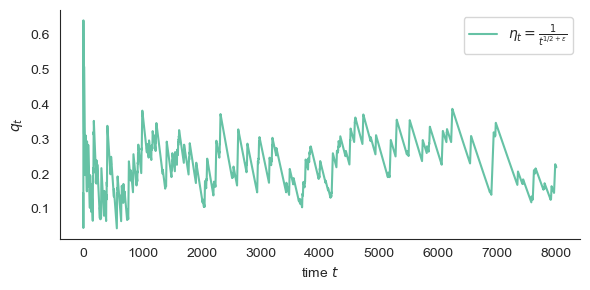

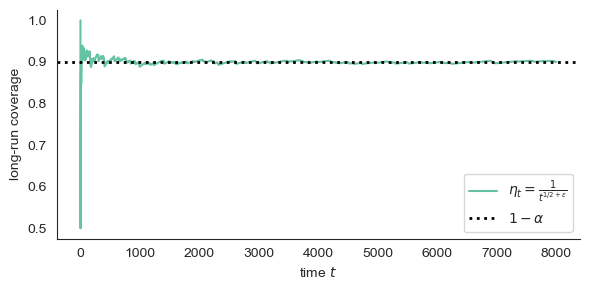

0.2365304765178434


In [8]:
simple_average_pred = simple_average_ensemble([y_garch_pred, y_garch_pred2, y_garch_pred3])
results_sa_garch = compute_coverage_metrics(y_true_test, simple_average_pred, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_sa_garch, alpha=0.1, W=1000)
print(np.mean(results_sa_garch['q_decaying']))
CI_sa_decaying = results_sa_garch['q_decaying'] * 2

## Super Learner 

Fold 0: train=5335, val=5333


100%|██████████| 5333/5333 [00:44<00:00, 119.97it/s]


Fold 1: train=10668, val=5333


100%|██████████| 5333/5333 [00:45<00:00, 117.79it/s]


Fold 2: train=16001, val=5333


...

100%|██████████| 5333/5333 [01:04<00:00, 82.34it/s] 


Fold 4: train=26667, val=5333


100%|██████████| 5333/5333 [01:24<00:00, 63.47it/s]


Final meta-learner weights: [0.18447809 0.18436527 0.63115664]


100%|██████████| 8000/8000 [02:35<00:00, 51.59it/s]


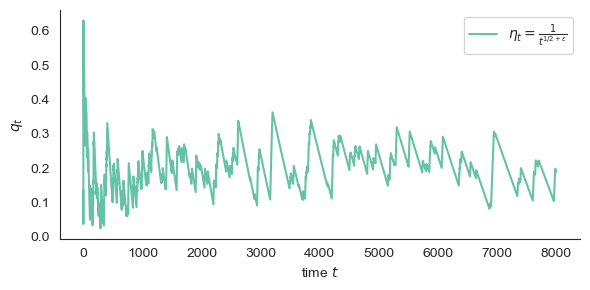

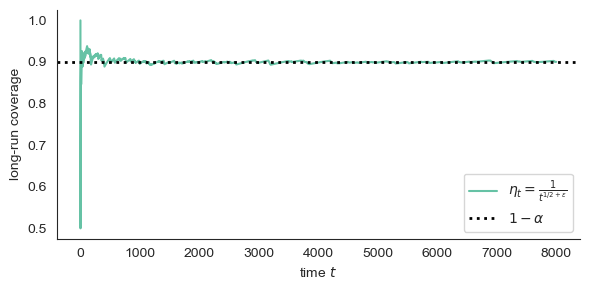

sl 0.900375


In [9]:
def garch_forecast(data, train_size, horizon=1, refit_every=50,
                   mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t'):
    """
    Rolling GARCH forecast with optional AR mean and less frequent refits.

    Parameters:
        data (array-like): time series (e.g., returns).
        train_size (int): number of points in training set.
        horizon (int): forecast horizon (default = 1).
        refit_every (int): how often to refit the GARCH model (default=50).
        mean (str): mean model type ('Zero', 'Constant', 'AR').
        lags (int): number of AR lags if mean='AR'.
        vol (str): volatility model type ('GARCH', 'EGARCH', etc.).
        p, q (int): GARCH orders.
        dist (str): error distribution ('normal', 't', 'skewt', 'ged').

    Returns:
        np.array: mean forecasts for the test set.
    """
    data = np.asarray(data, dtype=float)
    train, test = data[:train_size], data[train_size:]
    
    preds = []
    res = None
    for t in tqdm(range(len(test))):
        if t % refit_every == 0 or res is None:
            train_subset = np.concatenate([train, test[:t]])
            model = arch_model(train_subset,
                               mean=mean, lags=lags,
                               vol=vol, p=p, q=q, dist=dist)
            res = model.fit(disp="off")
        
        forecast = res.forecast(horizon=horizon, reindex=False)
        pred = forecast.mean.iloc[-1, 0]
        preds.append(pred)
    
    return np.array(preds)

def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    init_phi = np.ones(X.shape[1]) / X.shape[1]
    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2
    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]
    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x


def super_learner_garch(y, n_splits=5, refit_every=20):
    """
    Super Learner with 3 base GARCH learners: (1,1), (2,2), (3,3).
    Uses the same rolling garch_forecast() as standalone.
    """
    n_total = len(y)
    train_size = int(0.8 * n_total)
    y_train, y_test = y[:train_size], y[train_size:]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    meta_features = np.full((train_size, 3), np.nan)

    # --- 1. Cross-validation (OOF preds) ---
    for fold, (train_idx, val_idx) in enumerate(tscv.split(y_train)):
        print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")

        # Data up to the end of this fold
        cv_data = y_train[:max(val_idx) + 1]

        # Run the same rolling GARCH base learner
        preds1 = garch_forecast(cv_data, len(train_idx),
                                mean='AR', lags=1, p=1, q=1, dist='t',
                                refit_every=refit_every)
        preds2 = garch_forecast(cv_data, len(train_idx),
                                lags=1, vol='EGARCH', p=1, q=1,
                                dist='t', refit_every=20)
        preds3 = garch_forecast(cv_data, len(train_idx),
                                mean='AR', lags=2, vol='GARCH', p=2, q=2, dist='skewt', refit_every=50)

        # Keep only predictions corresponding to this validation window
        meta_features[val_idx, 0] = preds1[-len(val_idx):]
        meta_features[val_idx, 1] = preds2[-len(val_idx):]
        meta_features[val_idx, 2] = preds3[-len(val_idx):]

    # Drop NaN rows
    valid_rows = ~np.isnan(meta_features).any(axis=1)
    X_meta = meta_features[valid_rows]
    y_meta = y_train[valid_rows]

    # --- 2. Meta-learning (convex weights) ---
    meta_weights = optimize_weights(X_meta, y_meta)
    print("Final meta-learner weights:", meta_weights)

    # --- 3. Final refit on full training set ---
    garch_full1 = garch_forecast(y, train_size,
                                 mean='AR', lags=1, p=1, q=1, dist='t',
                                 refit_every=refit_every)
    garch_full2 = garch_forecast(y, train_size,
                                  mean='AR', lags=1, vol='EGARCH', p=1, q=1,
                                  dist='t', refit_every=20)
    garch_full3 = garch_forecast(y, train_size,
                                  mean='AR', lags=2, vol='GARCH', p=2, q=2, dist='skewt', refit_every=50)

    X_test_meta = np.column_stack([garch_full1, garch_full2, garch_full3])
    super_preds = X_test_meta @ meta_weights

    return super_preds, meta_weights

# --- Usage ---
y = y_observed.to_numpy()
super_preds, meta_weights = super_learner_garch(y, n_splits=5)

# Evaluate coverage
results_sl = compute_coverage_metrics(
    y_true_test, super_preds,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)
plot_coverage_results(results_sl, alpha=0.1, W=1000)

print(f"sl", np.mean(results_sl['observed_coverages_decaying']))

### Comparison 

0.20243568773164497


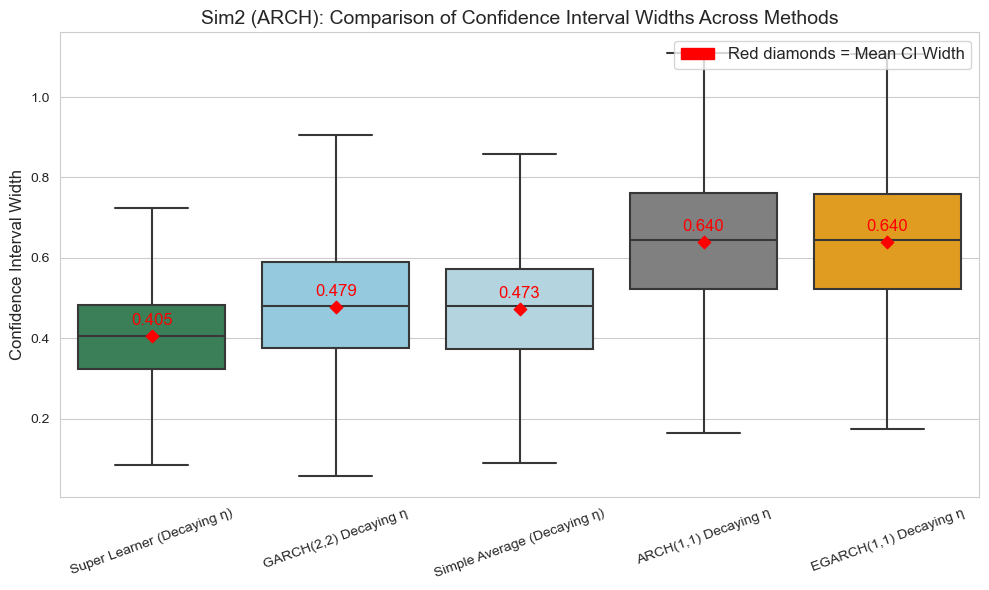

In [18]:
CI_sp_decaying = results_sl['q_decaying'] * 2 
print(np.mean(results_sl['q_decaying']))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
# Step 1: Collect all CI width arrays into a dictionary
data_dict = {
    "ARCH(1,1) Decaying η": CI_garch_decaying,
    "EGARCH(1,1) Decaying η": CI_garch_decaying2,
    "GARCH(2,2) Decaying η": CI_garch_decaying3,
    "Simple Average (Decaying η)": CI_sa_decaying,
    "Super Learner (Decaying η)": CI_sp_decaying
}

# Step 2: Convert to long-format DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 3: Define custom order by median CI width
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

# Step 4: Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
palette = {
    "ARCH(1,1) Decaying η": "gray",
    "EGARCH(1,1) Decaying η": "orange",
    "GARCH(2,2) Decaying η": "skyblue",
    "Simple Average (Decaying η)": "lightblue",
    "Super Learner (Decaying η)": "seagreen"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

# Add mean points
means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.3f}",
            ha='center', va='bottom', fontsize=12, color="red")

# Step 5: Add custom legend entry for red mean points
mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=12, frameon=True)

# Step 6: Enhance readability
plt.title("Sim2 (ARCH): Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



Mean deterministic coverage: 0.898875
Mean randomized coverage: 0.898875
Mean CI width — COMA (det): 0.4786794634270031
Mean CI width — COMA (rand): 0.47861244100611294
Mean CI width — Super Learner: 0.40487137546328994


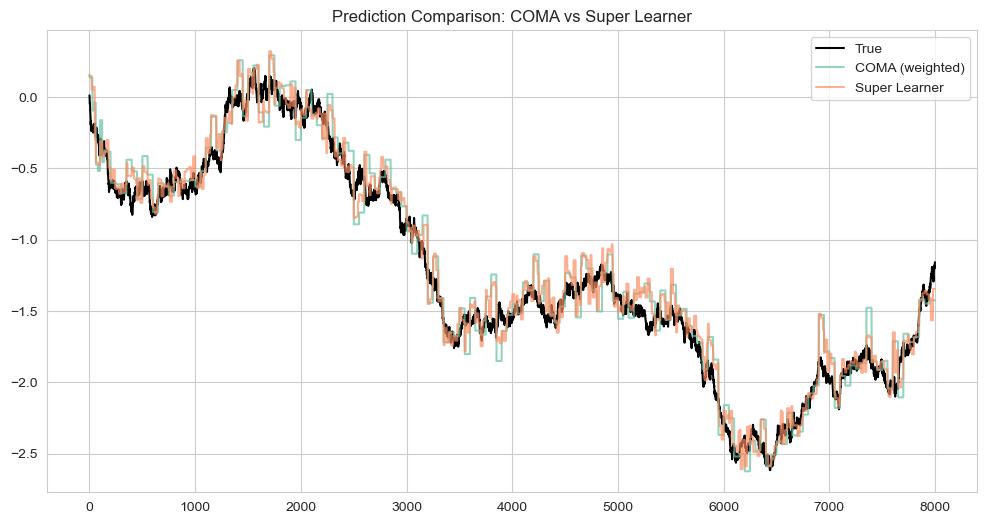

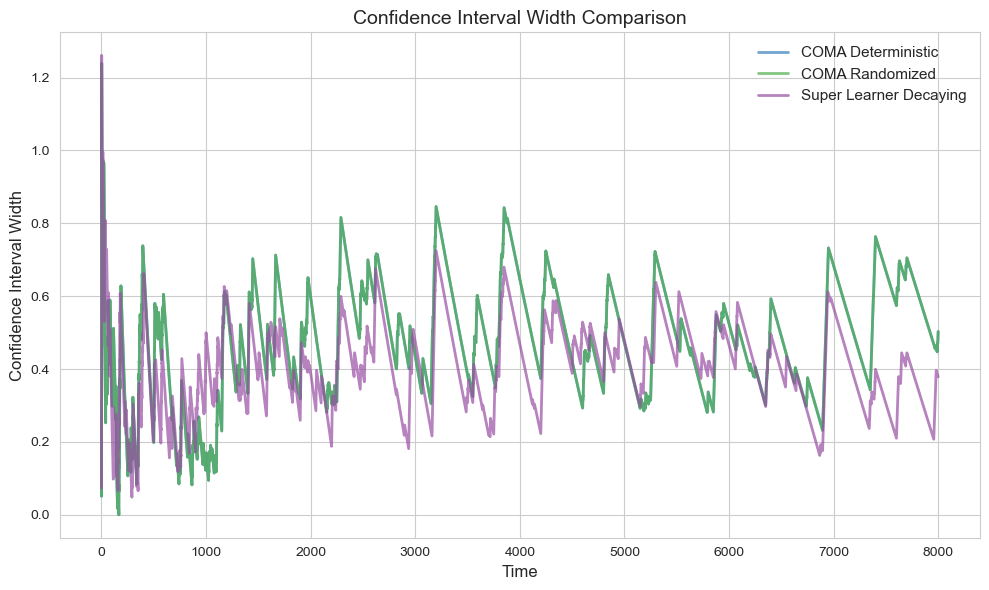

In [11]:
colors = sns.color_palette("Set1", 4)
# --- Step 1: Minimum aligned length ---
min_len = min(
    len(results_garch['q_decaying']),
    len(results_garch2['q_decaying']),
    #len(results_jd_srm_model2['q_decaying']),
    len(results_garch3['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(CI_sa_decaying),
    len(CI_sp_decaying),
    len(y_true_test)
)

# --- Step 2: CI half-widths (2 * q_decaying) ---
ci_matrix = np.column_stack([
    CI_garch_decaying[-min_len:],
    CI_garch_decaying2[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_garch_decaying3[-min_len:],
    #2 * results_jd_lstm3_model2['q_decaying'][:min_len]

])
adahedAlg = adahedge(loss_matrix=ci_matrix)

intervals_garch = np.column_stack([
    y_garch_pred[-min_len:] 
    - results_garch['q_decaying'][-min_len:],
    y_garch_pred[-min_len:] 
    + results_garch['q_decaying'][-min_len:]
])

intervals_garch2 = np.column_stack([
    y_garch_pred2[-min_len:] - results_garch2['q_decaying'][-min_len:],
    y_garch_pred2[-min_len:] + results_garch2['q_decaying'][-min_len:]
])

intervals_garch3 = np.column_stack([
    y_garch_pred3[-min_len:] - results_garch3['q_decaying'][-min_len:],
    y_garch_pred3[-min_len:] + results_garch3['q_decaying'][-min_len:]
])


intervals_list_plain = [intervals_garch, intervals_garch2, intervals_garch3]
weights_plain = adahedAlg["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])

# --- Step 7: Compute widths ---
pi_m   = result_plain["pi_m"]
pi_wm  = result_plain["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sp_decaying[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

base_preds_matrix = np.column_stack([
    y_garch_pred[-min_len:],
    y_garch_pred2[-min_len:],
    y_garch_pred3[-min_len:]
])
# Case 1: weights_plain is shape (n, k)
coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

# --- Step 8: Plot ---
plt.figure(figsize=(10, 6))

plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner Decaying', linewidth=2, alpha = 0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

## COMA

### Adahedge

Mean deterministic coverage: 0.897625
Mean randomized coverage: 0.897
Mean CI width — COMA (det): 0.4786794634270031
Mean CI width — COMA (rand): 0.47859528628718034
Mean CI width — COMA (det) + SL: 0.4049763215855165
Mean CI width — COMA (rand) + SL: 0.4044384311709473


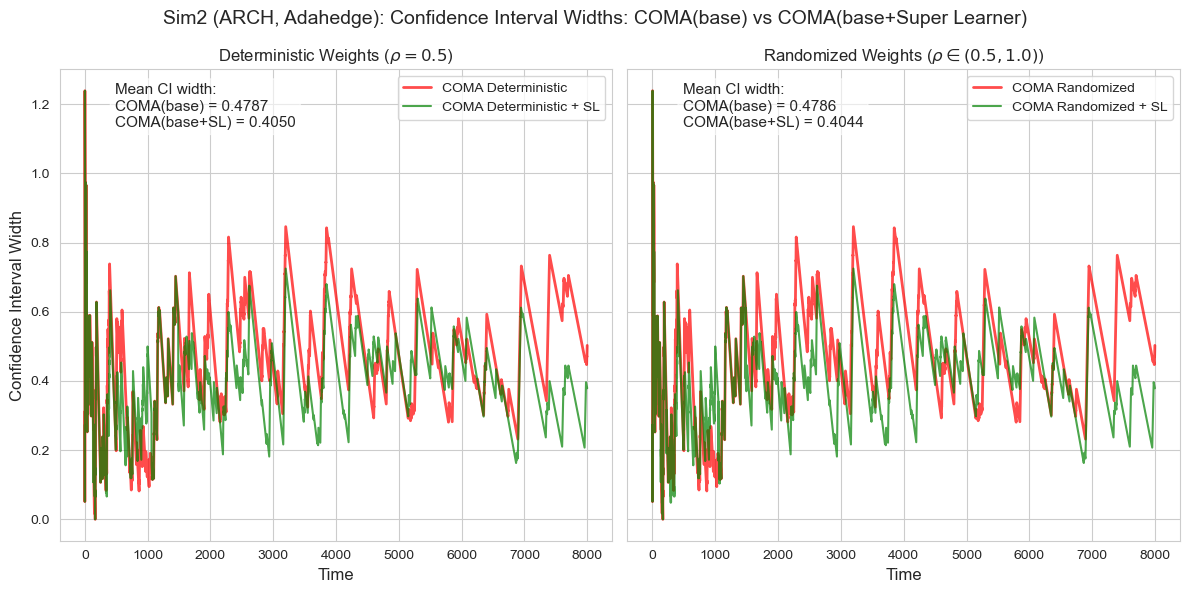

In [22]:

min_len = min(
    len(results_garch['q_decaying']),
    len(results_garch2['q_decaying']),
    len(results_garch['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(results_sl['q_decaying']),
    len(y_true_test)
)

ci_matrix_sl = np.column_stack([
    CI_garch_decaying[-min_len:],
    CI_garch_decaying2[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_garch_decaying3[-min_len:],
    CI_sp_decaying[-min_len:]
])
adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)

intervals_garch = np.column_stack([
    y_garch_pred[-min_len:] 
    - results_garch['q_decaying'][-min_len:],
    y_garch_pred[-min_len:] 
    + results_garch['q_decaying'][-min_len:]
])

intervals_garch2 = np.column_stack([
    y_garch_pred2[-min_len:] - results_garch2['q_decaying'][-min_len:],
    y_garch_pred2[-min_len:] + results_garch2['q_decaying'][-min_len:]
])

intervals_garch3 = np.column_stack([
    y_garch_pred3[-min_len:] - results_garch3['q_decaying'][-min_len:],
    y_garch_pred3[-min_len:] + results_garch3['q_decaying'][-min_len:]
])



intervals_sp = np.column_stack([
    super_preds[-min_len:] - results_sl['q_decaying'][-min_len:],
    super_preds[-min_len:] + results_sl['q_decaying'][-min_len:]
])

# --- Step 4: Pack intervals + weights ---
intervals_list_sl = [intervals_garch, intervals_garch2, intervals_garch3, intervals_sp]
weights_sl = adahedAlg_sl["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_sl = coma_loop(intervals_list_sl, weights_sl, y_test_aligned)

print("Mean deterministic coverage:", result_sl["mean_m_cov"])
print("Mean randomized coverage:", result_sl["mean_wm_cov"])


intervals_list_plain = [intervals_garch, intervals_garch2, intervals_garch3]
weights_plain = adahedAlg["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)
# --- Step 7: Compute widths ---
pi_m_plain   = result_plain["pi_m"]
pi_wm_plain  = result_plain["pi_wm"]
coma_width_det  = np.array([loss_fun(ci) for ci in pi_m_plain])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm_plain])
# --- Step 7: Compute widths ---
pi_m_sl   = result_sl["pi_m"]
pi_wm_sl  = result_sl["pi_wm"]

coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA (det) + SL:", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color='red')
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color='green')
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Add mean values annotation
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.97,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Add mean values annotation
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.97,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim2 (ARCH, Adahedge): Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.show()

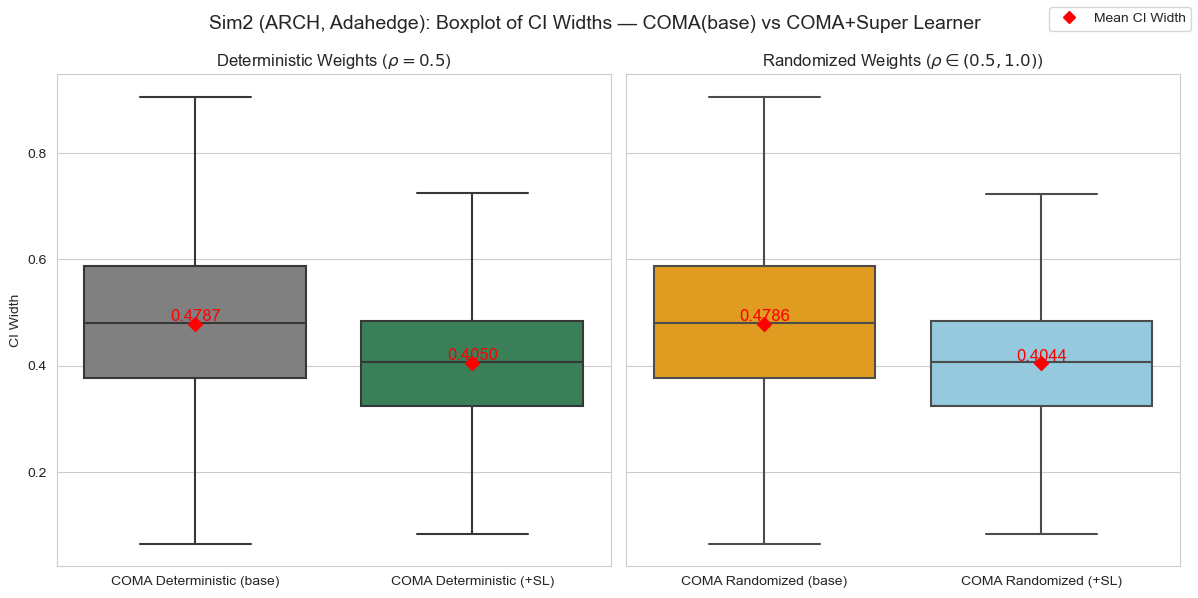

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Collect into dictionary
data_dict = {
    "COMA Deterministic (base)": coma_width_det,
    "COMA Deterministic (+SL)": coma_width_det_sl,
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

# Convert to DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Split deterministic vs randomized
det_methods = ["COMA Deterministic (base)", "COMA Deterministic (+SL)"]
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

palette = {"COMA Deterministic (base)": "gray",
           "COMA Deterministic (+SL)": "seagreen",
           "COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

# --- Deterministic subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(det_methods)],
            order=det_methods, palette=palette, showfliers=False, ax=axes[0])

means_det = [np.nanmean(data_dict[m]) for m in det_methods]
for i, m in enumerate(det_methods):
    axes[0].scatter(i, means_det[i], color="red", marker="D", s=50, zorder=3)
    axes[0].text(i, means_det[i]+0.005, f"{means_det[i]:.4f}", ha='center', fontsize=12, color="red")

axes[0].set_title("Deterministic Weights ($\\rho=0.5$)")
axes[0].set_xlabel("")
axes[0].set_ylabel("CI Width")

# --- Randomized subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(rand_methods)],
            order=rand_methods, palette=palette, showfliers=False, ax=axes[1])

means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    axes[1].scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    axes[1].text(i, means_rand[i]+0.005, f"{means_rand[i]:.4f}", ha='center', fontsize=12, color="red")

axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Legend for red diamond
fig.legend(handles=[plt.Line2D([0],[0], color='red', marker='D', linestyle='', label='Mean CI Width')],
           loc='upper right')

plt.suptitle("Sim2 (ARCH, Adahedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

### adahedge_smooth

Mean CI width — COMA(base, det): 0.4783898995699197
Mean CI width — COMA(base, rand): 0.47838305067198483
Mean CI width — COMA(base+SL, det): 0.41460395563290686
Mean CI width — COMA(base+SL, rand): 0.4142936918764971


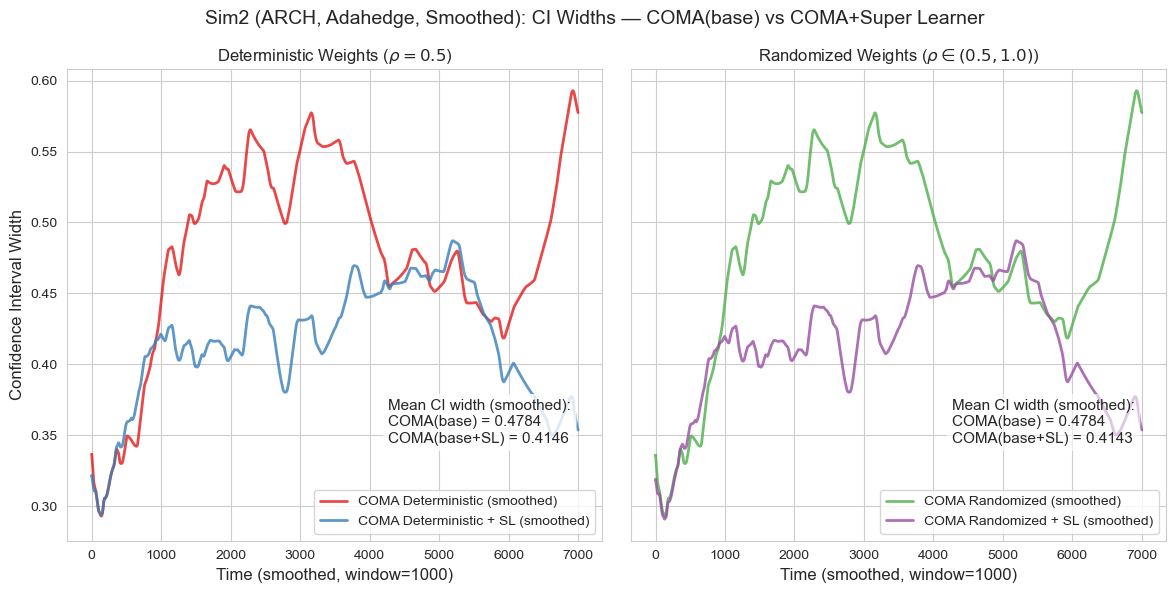

In [24]:
import numpy as np
import matplotlib.pyplot as plt
def smooth_series(series, window=500):
    """Apply rolling mean smoothing with specified window size."""
    return np.convolve(series, np.ones(window)/window, mode='valid')

coma_width_det_smooth     = smooth_series(coma_width_det, window=1000)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
coma_width_det_sl_smooth  = smooth_series(coma_width_det_sl, window=1000)
coma_width_rand_sl_smooth = smooth_series(coma_width_rand_sl, window=1000)

# --- Step 5: Summaries (on smoothed series) ---
print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det_smooth))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand_smooth))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl_smooth))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl_smooth))

# --- Step 6: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det_smooth, label='COMA Deterministic (smoothed)', linewidth=2, alpha=0.8, color=colors[0])
axes[0].plot(coma_width_det_sl_smooth, label='COMA Deterministic + SL (smoothed)', linewidth=2, alpha=0.8, color=colors[1])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det_smooth)
mean_det_sl = np.nanmean(coma_width_det_sl_smooth)
axes[0].text(0.6, 0.3,
             f"Mean CI width (smoothed):\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand_smooth, label='COMA Randomized (smoothed)', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(coma_width_rand_sl_smooth, label='COMA Randomized + SL (smoothed)', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand_smooth)
mean_rand_sl = np.nanmean(coma_width_rand_sl_smooth)
axes[1].text(0.6, 0.3,
             f"Mean CI width (smoothed):\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim2 (ARCH, Adahedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

### Hedge 

Mean deterministic coverage (COMA base): 0.898625
Mean randomized coverage (COMA base): 0.89725
Mean deterministic coverage (COMA+SL): 0.89875
Mean randomized coverage (COMA+SL): 0.892
Mean CI width — COMA(base, det): 0.4795200703840011
Mean CI width — COMA(base, rand): 0.4768304652324014
Mean CI width — COMA(base+SL, det): 0.4052846684336577
Mean CI width — COMA(base+SL, rand): 0.39713658486626946


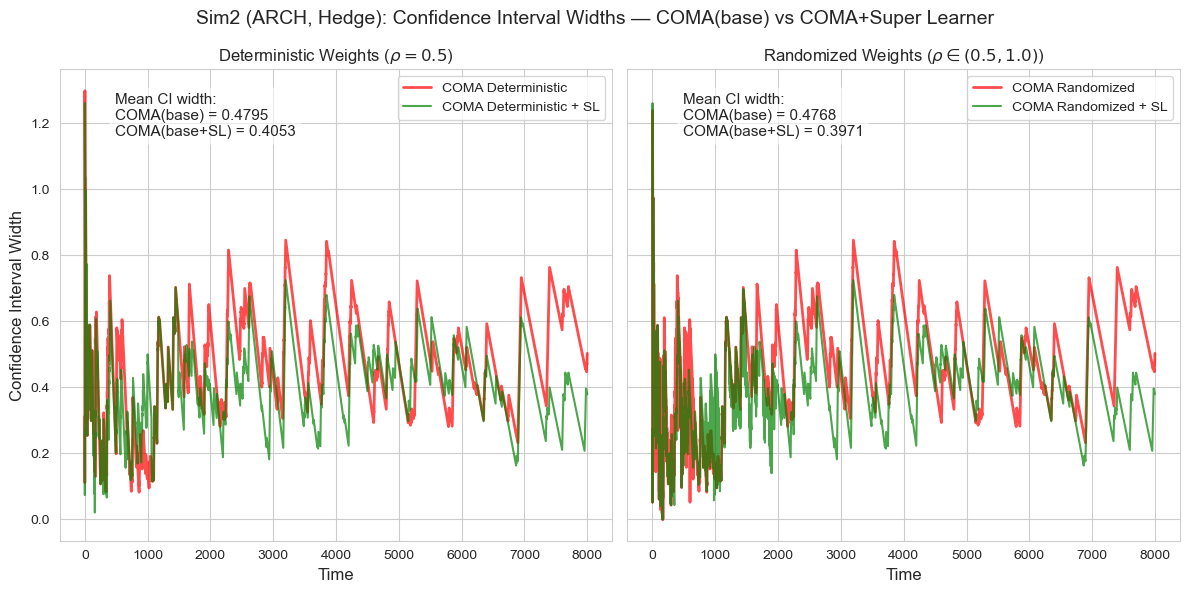

In [19]:
# --- Step 1: Run Hedge separately for base (3 experts) and base+SL (4 experts) ---
hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)
hedAlg_sl   = hedge(ci_matrix_sl, eta=0.1)     # shape (N,4)

weights_base = hedAlg_base["weights"]
weights_sl   = hedAlg_sl["weights"]

N_base, K_base = weights_base.shape
N_sl, K_sl     = weights_sl.shape

# Ensure alignment
min_len = min(len(y_true_test), N_base, N_sl)
y_test_aligned = y_true_test[-min_len:]

# --- Step 2: Preallocate ---
pi_m_base, pi_wm_base = [], []
pi_m_sl, pi_wm_sl     = [], []

m_cov_base = np.full(min_len, np.nan)
wm_cov_base = np.full(min_len, np.nan)
m_cov_sl   = np.full(min_len, np.nan)
wm_cov_sl  = np.full(min_len, np.nan)

# --- Step 3: Loop over time ---
for i in range(min_len):
    # --- Sample ONE rho per step and reuse for both base and base+SL ---
    rho_rand = np.random.uniform(0.5,1.0)

    # --- Base (3 experts) ---
    conf_base = np.vstack([intervals_list_plain[j][i] for j in range(3)])
    maj_int_base = majority_vote(conf_base, w=weights_base[i], rho=0.5)
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=rho_rand)

    pi_m_base.append(maj_int_base)
    pi_wm_base.append(wmaj_int_base)
    m_cov_base[i]  = covr_fun(maj_int_base, y_test_aligned[i])
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

    # --- Base+SL (4 experts) ---
    conf_sl = np.vstack([intervals_list_sl[j][i] for j in range(4)])
    maj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=0.5)
    wmaj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=rho_rand)  # same rho_rand

    pi_m_sl.append(maj_int_sl)
    pi_wm_sl.append(wmaj_int_sl)
    m_cov_sl[i]  = covr_fun(maj_int_sl, y_test_aligned[i])
    wm_cov_sl[i] = covr_fun(wmaj_int_sl, y_test_aligned[i])

# --- Step 4: Compute widths ---
coma_width_det     = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

# --- Step 5: Summaries ---
print("Mean deterministic coverage (COMA base):", np.nanmean(m_cov_base))
print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean deterministic coverage (COMA+SL):", np.nanmean(m_cov_sl))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))

# --- Step 7: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color='red')
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color='green')
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim2 (ARCH, Hedge): Confidence Interval Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

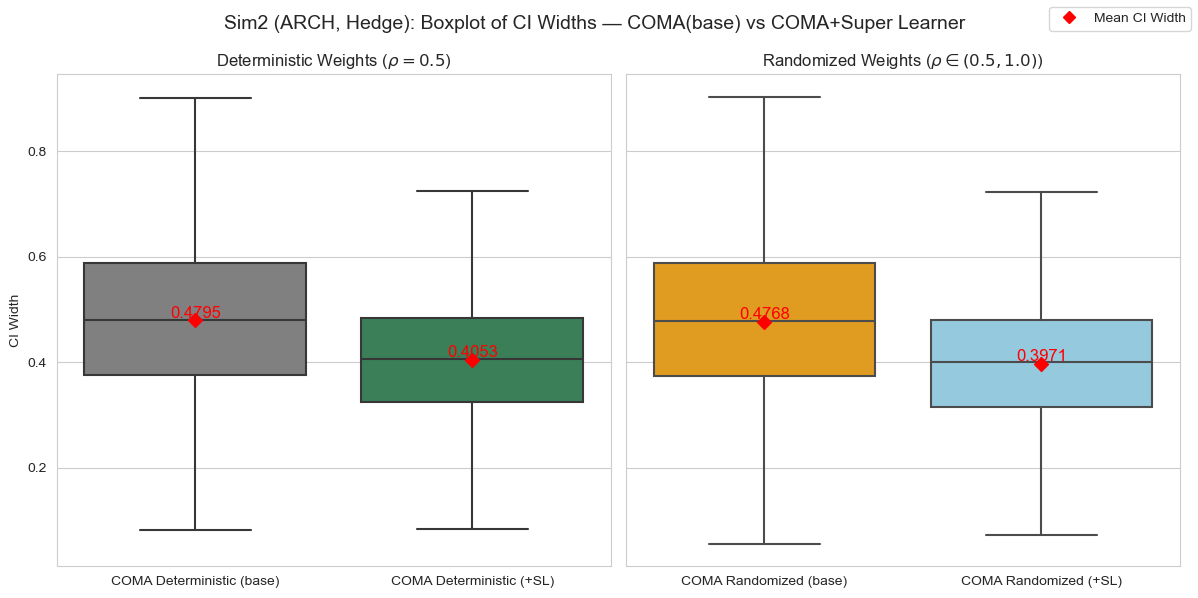

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Collect into dictionary
data_dict = {
    "COMA Deterministic (base)": coma_width_det,
    "COMA Deterministic (+SL)": coma_width_det_sl,
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

# Convert to DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Split deterministic vs randomized
det_methods = ["COMA Deterministic (base)", "COMA Deterministic (+SL)"]
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

palette = {"COMA Deterministic (base)": "gray",
           "COMA Deterministic (+SL)": "seagreen",
           "COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

# --- Deterministic subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(det_methods)],
            order=det_methods, palette=palette, showfliers=False, ax=axes[0])

means_det = [np.nanmean(data_dict[m]) for m in det_methods]
for i, m in enumerate(det_methods):
    axes[0].scatter(i, means_det[i], color="red", marker="D", s=50, zorder=3)
    axes[0].text(i, means_det[i]+0.005, f"{means_det[i]:.4f}", ha='center', fontsize=12, color="red")

axes[0].set_title("Deterministic Weights ($\\rho=0.5$)")
axes[0].set_xlabel("")
axes[0].set_ylabel("CI Width")

# --- Randomized subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(rand_methods)],
            order=rand_methods, palette=palette, showfliers=False, ax=axes[1])

means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    axes[1].scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    axes[1].text(i, means_rand[i]+0.005, f"{means_rand[i]:.4f}", ha='center', fontsize=12, color="red")

axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Legend for red diamond
fig.legend(handles=[plt.Line2D([0],[0], color='red', marker='D', linestyle='', label='Mean CI Width')],
           loc='upper right')

plt.suptitle("Sim2 (ARCH, Hedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

#### hedge-smooth

Mean CI width — COMA(base, det): 0.47854635901976095
Mean CI width — COMA(base, rand): 0.4778892423394011
Mean CI width — COMA(base+SL, det): 0.4146632155621245
Mean CI width — COMA(base+SL, rand): 0.40849844079304054


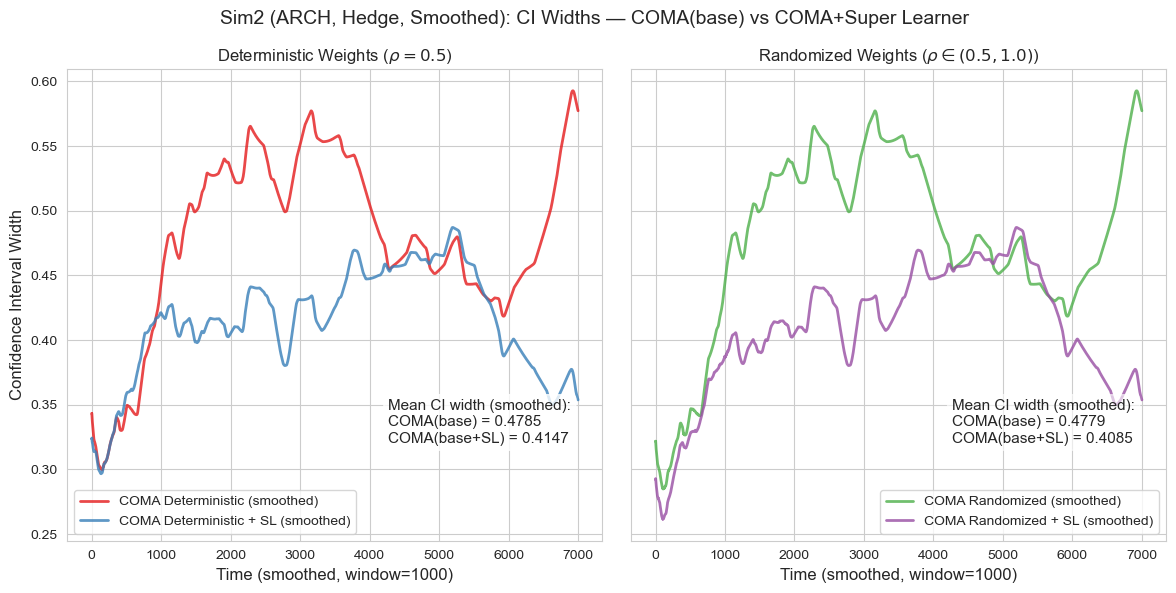

In [21]:
import numpy as np
import matplotlib.pyplot as plt
def smooth_series(series, window=500):
    """Apply rolling mean smoothing with specified window size."""
    return np.convolve(series, np.ones(window)/window, mode='valid')

coma_width_det_smooth     = smooth_series(coma_width_det, window=1000)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
coma_width_det_sl_smooth  = smooth_series(coma_width_det_sl, window=1000)
coma_width_rand_sl_smooth = smooth_series(coma_width_rand_sl, window=1000)

# --- Step 5: Summaries (on smoothed series) ---
print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det_smooth))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand_smooth))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl_smooth))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl_smooth))

# --- Step 6: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det_smooth, label='COMA Deterministic (smoothed)', linewidth=2, alpha=0.8, color=colors[0])
axes[0].plot(coma_width_det_sl_smooth, label='COMA Deterministic + SL (smoothed)', linewidth=2, alpha=0.8, color=colors[1])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det_smooth)
mean_det_sl = np.nanmean(coma_width_det_sl_smooth)
axes[0].text(0.6, 0.3,
             f"Mean CI width (smoothed):\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand_smooth, label='COMA Randomized (smoothed)', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(coma_width_rand_sl_smooth, label='COMA Randomized + SL (smoothed)', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand_smooth)
mean_rand_sl = np.nanmean(coma_width_rand_sl_smooth)
axes[1].text(0.6, 0.3,
             f"Mean CI width (smoothed):\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim2 (ARCH, Hedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()